# Polarizability Comparison: Manual (NIST Sum) vs. ARC Package

This notebook compares the scalar and vector polarizabilities calculated using the legacy manual summation method (summing over experimental transition lines) and the newly integrated ARC (Alkali.ne Rydberg Calculator) package.

In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import scipy.constants as const

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.polarizabilities_calculation as E9pol
import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Setup logging to avoid clutter
logging.getLogger().setLevel(logging.ERROR)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
def mark_important_lines(ax, lines, f_min, l_alpha = None, init_text_height = 0):
    """Label the important transitions on the plot."""
    y_min, y_max = ax.get_ylim()
    text_ypos = init_text_height
    vcolor = l_alpha.get_color() if l_alpha else '#888888'
        
    for line in lines:
        if line['f_ik'] is not None and line['f_ik'] >= f_min:
            lamb_nm = line['lambda'] * 1e9
            if ax.get_xlim()[0] <= lamb_nm <= ax.get_xlim()[1]:
                gs, es, iso = line['gs'], line['es'], line['isotope']
                level_text = iso + gs.replace('o', '/') + '->' + es.replace('o', '/')
                ax.axvline(x = lamb_nm, color = vcolor, linestyle = ':', alpha = 0.5)
                ax.text(lamb_nm, y_min + (y_max - y_min) * (0.1 + 0.08 * (text_ypos % 8)), 
                        level_text, color = vcolor, fontsize = 9, rotation=90, verticalalignment='bottom')
                text_ypos += 1

In [3]:
# Common parameters
pol_SI2au = 1/1.64877727436e-41
wavelengths = np.linspace(400, 1600, 5000) * 1e-9 

ylim_s = 2e3
ylim_v = 20
notable_f = 0.01

In [9]:
print("Calculating polarizabilities...")
# Manual (Valence states only)
print("working on manual...")
alpha_s_K_man = E9pol.get_polarizability(wavelengths, 0, method="MANUAL", line_list=TLData.K_4S1o2_lines, state='4S1o2')
alpha_s_Rb_man = E9pol.get_polarizability(wavelengths, 0, method="MANUAL", line_list=TLData.Rb_5S1o2_lines, state='5S1o2')

# ARC (Valence only for direct comparison)
print("working on arc...")
alpha_s_K_arc = E9pol.get_polarizability(wavelengths, 0, method="ARC", arc_atom=E9c.K40, n=4, l=0, j=0.5, include_core=False)
alpha_s_Rb_arc = E9pol.get_polarizability(wavelengths, 0, method="ARC", arc_atom=E9c.Rb87, n=5, l=0, j=0.5, include_core=False)

# Vector (J level)
print("working on manual...")
alpha_v_K_man = E9pol.get_polarizability(wavelengths, 1, method="MANUAL", line_list=TLData.K_4S1o2_lines, state='4S1o2')
alpha_v_Rb_man = E9pol.get_polarizability(wavelengths, 1, method="MANUAL", line_list=TLData.Rb_5S1o2_lines, state='5S1o2')

print("working on arc...")
alpha_v_K_arc = E9pol.get_polarizability(wavelengths, 1, method="ARC", arc_atom=E9c.K40, n=4, l=0, j=0.5, include_core=False)
alpha_v_Rb_arc = E9pol.get_polarizability(wavelengths, 1, method="ARC", arc_atom=E9c.Rb87, n=5, l=0, j=0.5, include_core=False)

print("Done.")

Calculating polarizabilities...
working on manual...
working on arc...
working on manual...
working on arc...
Done.


## Scalar Polarizability Comparison

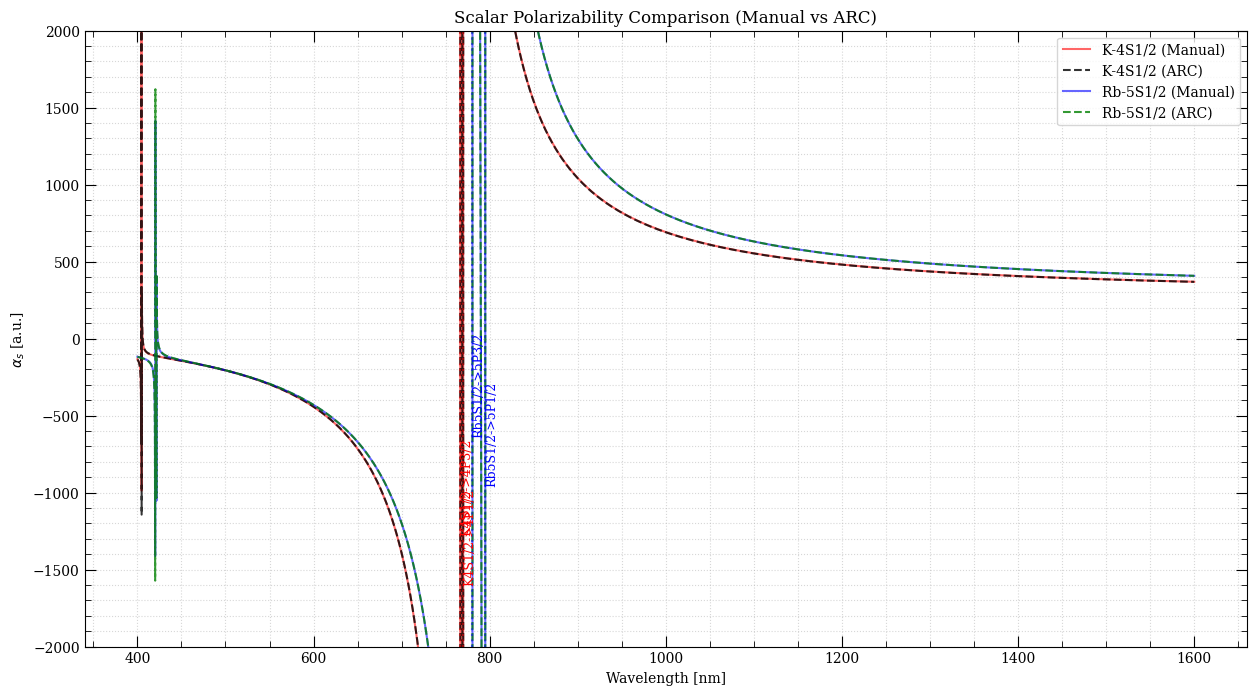

In [10]:
fig, ax = plt.subplots(figsize=(15, 8))

l1, = ax.plot(wavelengths * 1e9, alpha_s_K_man * pol_SI2au, 'r-', label='K-4S1/2 (Manual)', alpha=0.6)
ax.plot(wavelengths * 1e9, alpha_s_K_arc * pol_SI2au, 'k--', label='K-4S1/2 (ARC)', alpha=0.8)
l2, = ax.plot(wavelengths * 1e9, alpha_s_Rb_man * pol_SI2au, 'b-', label='Rb-5S1/2 (Manual)', alpha=0.6)
ax.plot(wavelengths * 1e9, alpha_s_Rb_arc * pol_SI2au, 'g--', label='Rb-5S1/2 (ARC)', alpha=0.8)

ax.set_ylim(-ylim_s, ylim_s)
ax.set_ylabel(r'$\alpha_s$ [a.u.]')
ax.set_xlabel('Wavelength [nm]')
ax.set_title("Scalar Polarizability Comparison (Manual vs ARC)")
ax.legend()
ax.grid(True, which='both', linestyle=':', alpha=0.5)

mark_important_lines(ax, TLData.K_4S1o2_lines, notable_f, l_alpha=l1)
mark_important_lines(ax, TLData.Rb_D12_doublet, notable_f, l_alpha=l2, init_text_height=2)

plt.show()

## Vector Polarizability Comparison

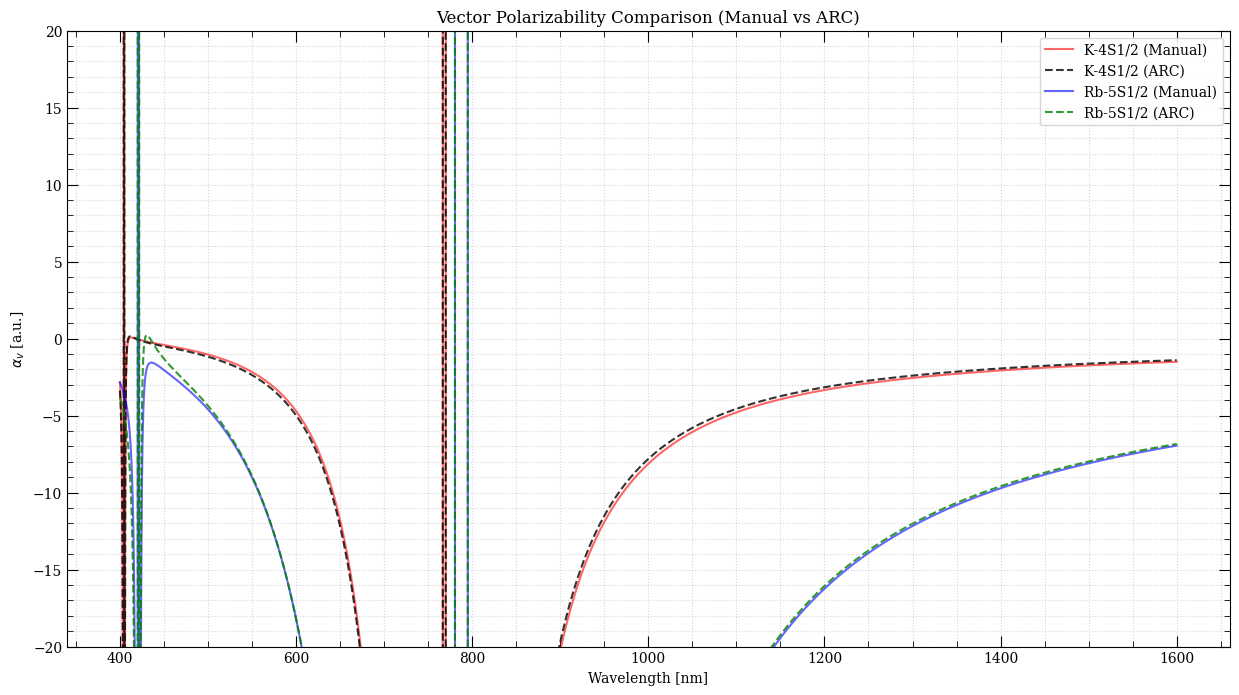

In [11]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(wavelengths * 1e9, alpha_v_K_man * pol_SI2au, 'r-', label='K-4S1/2 (Manual)', alpha=0.6)
ax.plot(wavelengths * 1e9, alpha_v_K_arc * pol_SI2au, 'k--', label='K-4S1/2 (ARC)', alpha=0.8)
ax.plot(wavelengths * 1e9, alpha_v_Rb_man * pol_SI2au, 'b-', label='Rb-5S1/2 (Manual)', alpha=0.6)
ax.plot(wavelengths * 1e9, alpha_v_Rb_arc * pol_SI2au, 'g--', label='Rb-5S1/2 (ARC)', alpha=0.8)

ax.set_ylim(-ylim_v, ylim_v)
ax.set_ylabel(r'$\alpha_v$ [a.u.]')
ax.set_xlabel('Wavelength [nm]')
ax.set_title("Vector Polarizability Comparison (Manual vs ARC)")
ax.legend()
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.show()

## Ratio $\alpha_v / \alpha_s$

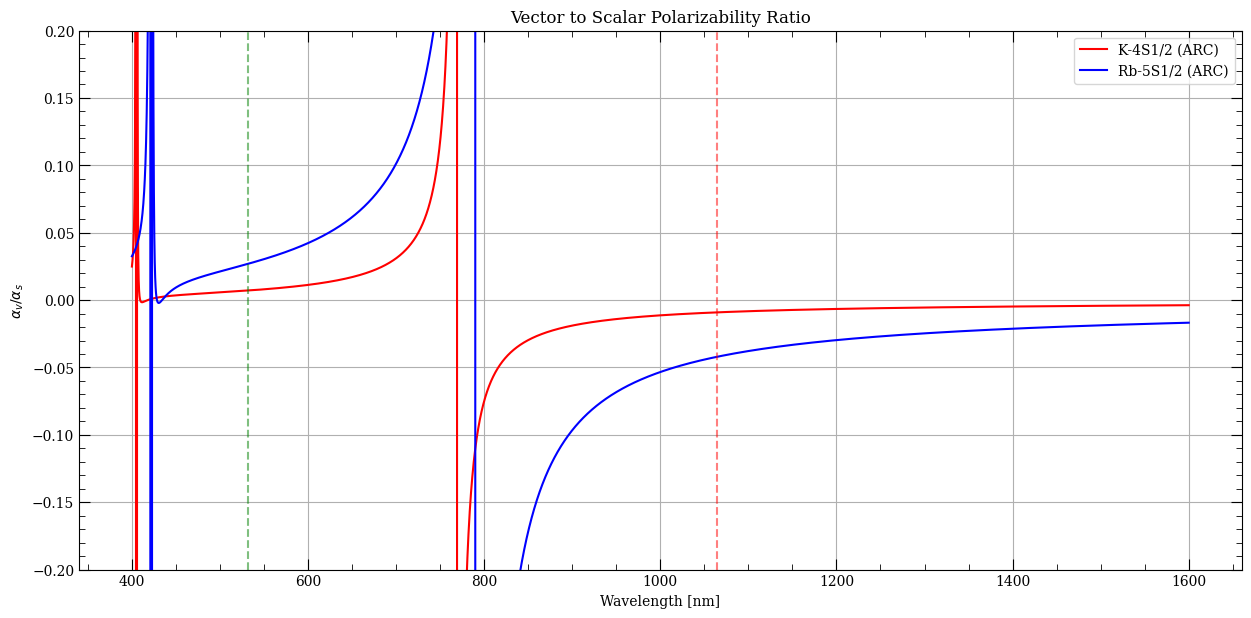

In [12]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(wavelengths * 1e9, alpha_v_K_arc/alpha_s_K_arc, 'r-', label='K-4S1/2 (ARC)')
ax.plot(wavelengths * 1e9, alpha_v_Rb_arc/alpha_s_Rb_arc, 'b-', label='Rb-5S1/2 (ARC)')

ax.set_ylim(-0.2, 0.2)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$\alpha_v/\alpha_s$')
ax.set_title("Vector to Scalar Polarizability Ratio")
ax.legend()
ax.grid(True)
ax.axvline(x = 532, color = 'green', alpha = 0.5, linestyle = '--', label='532 nm')
ax.axvline(x = 1064, color = 'red', alpha = 0.5, linestyle = '--', label='1064 nm')

plt.show()

## Percentage Difference (Manual vs ARC)

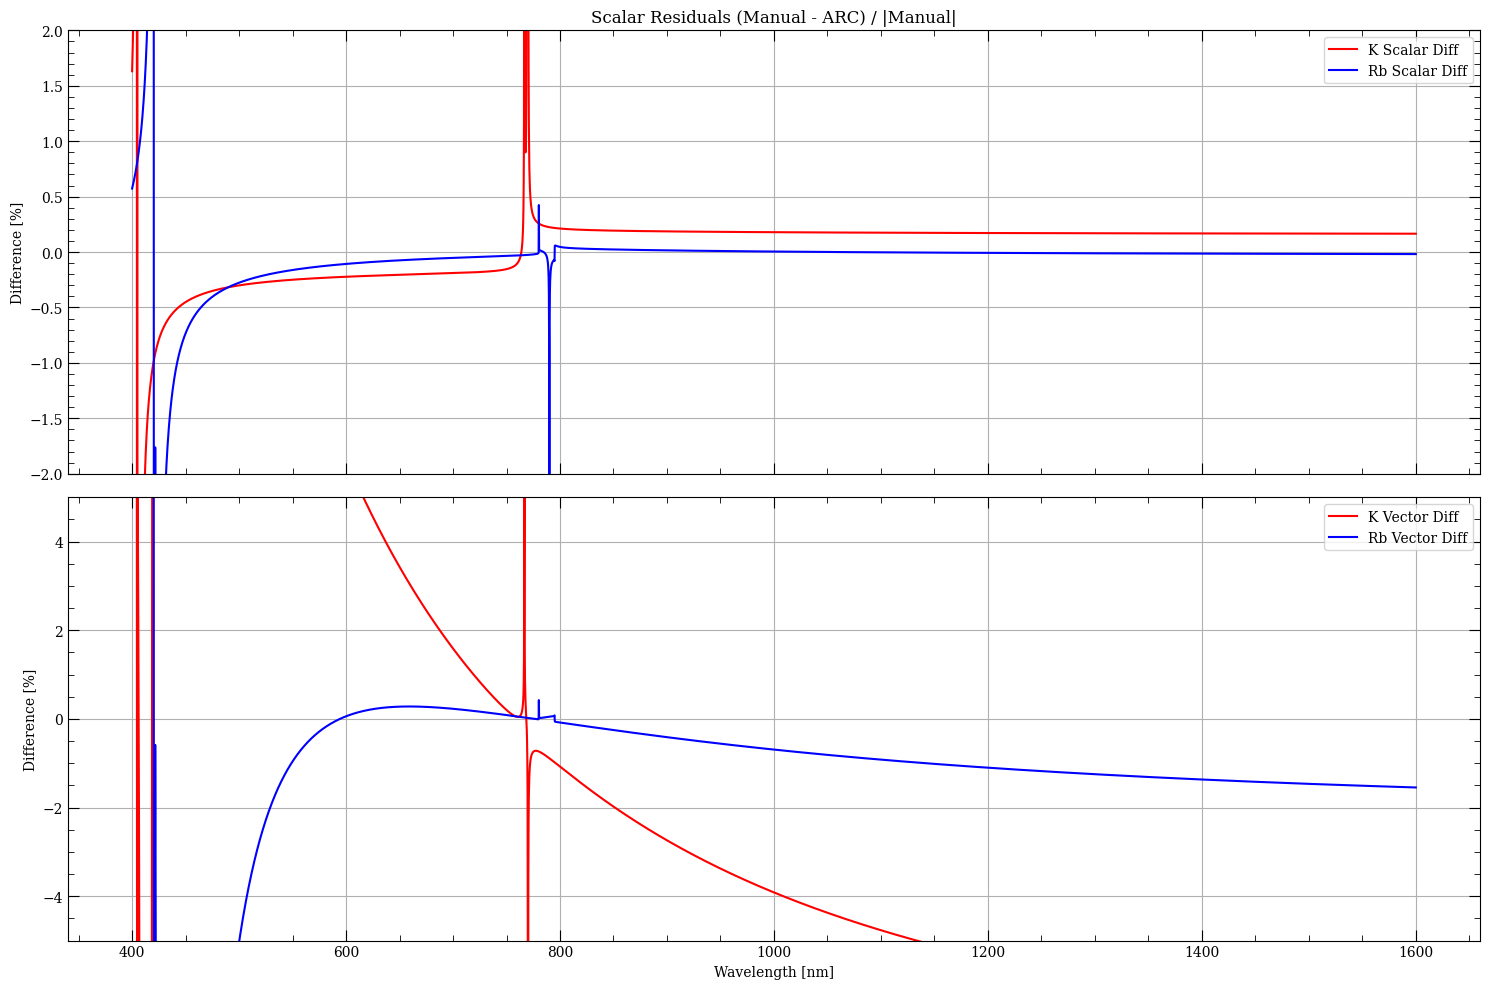

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

def safe_diff(man, arc):
    return 100 * (man - arc) / np.abs(man)

ax1.plot(wavelengths * 1e9, safe_diff(alpha_s_K_man, alpha_s_K_arc), 'r', label='K Scalar Diff')
ax1.plot(wavelengths * 1e9, safe_diff(alpha_s_Rb_man, alpha_s_Rb_arc), 'b', label='Rb Scalar Diff')
ax1.set_ylim(-2, 2)
ax1.set_ylabel('Difference [%]')
ax1.set_title("Scalar Residuals (Manual - ARC) / |Manual|")
ax1.legend()
ax1.grid(True)

ax2.plot(wavelengths * 1e9, safe_diff(alpha_v_K_man, alpha_v_K_arc), 'r', label='K Vector Diff')
ax2.plot(wavelengths * 1e9, safe_diff(alpha_v_Rb_man, alpha_v_Rb_arc), 'b', label='Rb Vector Diff')
ax2.set_ylim(-5, 5)
ax2.set_ylabel('Difference [%]')
ax2.set_xlabel('Wavelength [nm]')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()